# Modules
Imports the models needed for this analysis

In [107]:
# Modules
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
import sklearn.metrics as met 
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

# Data Collection
Loads the data which can be found on Github ([FPL Data](https://github.com/vaastav/Fantasy-Premier-League/tree/master/data))

In [108]:
data_file_path = 'C:/Users/lallen1/OneDrive - Thames Water Utilities Limited/Work/Personal/Apprenticeship/Year 1/Term 3 - Data Science Professional Practice/Formative/FPL_player_points_prediction/Data'
files = os.listdir(data_file_path)

# A list of the historical files
historical_data_files = files[:-1]
historical_data_files

['2016-17_merged_gw.csv',
 '2017-18_merged_gw.csv',
 '2018-19_merged_gw.csv',
 '2019-20_merged_gw.csv',
 '2020-21_merged_gw.csv',
 '2021-22_merged_gw.csv',
 '2022-23_merged_gw.csv',
 '2023-24_merged_gw.csv',
 '2024-25_merged_gw.csv']

### Example of the data

In [109]:
# Example of one of the dataset 
file_df = pd.read_csv('C:/Users/lallen1/OneDrive - Thames Water Utilities Limited/Work/Personal/Apprenticeship/Year 1/Term 3 - Data Science Professional Practice/Formative/FPL_player_points_prediction/Data/2016-17_merged_gw.csv',
                      encoding='latin-1')
file_df

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,...,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,winning_goals,yellow_cards,GW
0,Aaron_Cresswell,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,55,False,0,0,1
1,Aaron_Lennon,0,3,0,0,0,6,0,1,2,...,0,1,0,0,0,60,True,0,0,1
2,Aaron_Ramsey,0,26,0,0,0,5,0,2,22,...,23,2,0,0,0,80,True,0,0,1
3,Abdoulaye_Doucouré,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,50,False,0,0,1
4,Abdul Rahman_Baba,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,55,True,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23674,Yohan_Cabaye,0,65,0,0,3,42,0,5,57,...,117,10,-2177,152,2329,56,False,0,0,9
23675,Younes_Kaboul,0,34,0,0,0,23,1,7,28,...,12,6,1403,1897,494,44,False,0,0,9
23676,Zlatan_Ibrahimovic,0,40,0,0,0,8,0,4,35,...,56,2,-237262,4227,241489,113,False,0,0,9
23677,Álvaro_Arbeloa,0,0,0,0,0,0,0,0,0,...,0,0,-291,140,431,49,True,0,0,9


### Combining the historical data into a single dataset

In [110]:
# calculates the season for the data
def caculate_season(df,date_column) -> pd.DataFrame :
    '''
    Calculates the season for the data
    '''
    
    # caclulates the season
    year = pd.to_datetime(df[date_column]).dt.strftime('%y')
    year = year.iloc[0]
    season = year + '/' + str(int(year) + 1)
    df['season'] = season
    return df




In [111]:
# Combines the historical datasets together
historical_df = pd.DataFrame()

for file in historical_data_files:

    # Some of the files are encoded differently 
    for encoding in ['utf-8','latin-1']:
        try:
            file_df = pd.read_csv(f'{data_file_path}/{file}',encoding = 'utf-8')
            break
        except UnicodeDecodeError:
            continue
    # caclulates the season of each file
    caculate_season(file_df,'kickoff_time')

    # Joins the historical datasets into one dataset
    historical_df = pd.concat([historical_df, file_df])

historical_df

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,...,expected_goals_conceded,starts,mng_clean_sheets,mng_draw,mng_goals_scored,mng_loss,mng_underdog_draw,mng_underdog_win,mng_win,modified
0,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron_Lennon,0,3.0,0.0,0.0,0,6,0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aaron_Ramsey,0,26.0,0.0,0.0,0,5,0,2.0,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abdoulaye_Doucouré,0,0.0,0.0,0.0,0,0,0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Abdul Rahman_Baba,0,0.0,0.0,0.0,0,0,0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27600,Ashley Young,0,NaN,NaN,NaN,0,23,1,NaN,NaN,...,1.27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
27601,Somto Boniface,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
27602,Simon Rusk,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,0.00,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,False
27603,Arne Slot,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,0.00,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False


### Ingesting current seasons data

In [112]:
# Gets current season data
current_season_data = files[-1]
current_season_df = pd.read_csv(f'{data_file_path}/{current_season_data}',encoding = 'latin-1')
current_season_df = caculate_season(current_season_df,'kickoff_time')
current_season_df

,name,position,team,xP,assists,bonus,bps,clean_sheets,clearances_blocks_interceptions,creativity,...,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,season
0,Reinildo Mandava,DEF,Sunderland,0.5,0,0,27,1,6,2.5,...,0.0,6,0,0,0,40,True,0,1,25/26
1,Lewis Dobbin,MID,Aston Villa,1.0,0,0,0,0,0,0.0,...,0.0,0,0,0,0,50,True,0,1,25/26
2,Ryan Christie,MID,Bournemouth,0.0,0,0,0,0,0,0.0,...,0.0,0,0,0,0,50,False,0,1,25/26
3,Zeki Amdouni,FWD,Burnley,0.0,0,0,0,0,0,0.0,...,0.0,0,0,0,0,50,False,0,1,25/26
4,Lucas Tolentino Coelho de Lima,MID,West Ham,2.6,0,0,11,0,0,14.2,...,4.0,2,0,0,0,60,False,0,1,25/26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18178,Brian Brobbey,FWD,Sunderland,5.0,0,0,3,1,1,12.1,...,21.0,2,92097,110759,18662,56,True,0,24,25/26
18179,Evann Guessand,MID,Aston Villa,0.5,0,0,0,0,0,0.0,...,0.0,0,172,312,140,62,True,0,24,25/26
18180,Kaye Furo,FWD,Brentford,0.0,0,0,0,0,0,0.0,...,0.0,0,168,238,70,45,False,0,24,25/26
18181,Antony dos Santos,MID,Man Utd,0.0,0,0,0,0,0,0.0,...,0.0,0,-14,0,14,59,True,0,24,25/26


### Combining  the datasets
Combines the historical data of current players with the current seasons data; by doing this we remove any players that aren't currently active in FPL

In [113]:
# Combines the historical data of current players with the current seasons data
historical_current_players = historical_df[historical_df['name'].isin(current_season_df['name'])]
combined_df = pd.concat([historical_current_players, current_season_df], ignore_index=True)
combined_df['gw_season'] = ('season_' + combined_df['season'] + '_gw_' + combined_df['GW'].astype(str))
combined_df

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,...,mng_clean_sheets,mng_draw,mng_goals_scored,mng_loss,mng_underdog_draw,mng_underdog_win,mng_win,modified,defensive_contribution,gw_season
0,Aaron Ramsdale,0,NaN,NaN,NaN,0,12,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,season_20/21_gw_1
1,Adam Webster,0,NaN,NaN,NaN,0,14,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,season_20/21_gw_1
2,Alexis Mac Allister,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,season_20/21_gw_1
3,Alex Iwobi,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,season_20/21_gw_1
4,Alphonse Areola,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,season_20/21_gw_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65752,Brian Brobbey,0,NaN,NaN,NaN,0,3,1,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.0,season_25/26_gw_24
65753,Evann Guessand,0,NaN,NaN,NaN,0,0,0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0,season_25/26_gw_24
65754,Kaye Furo,0,NaN,NaN,NaN,0,0,0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0,season_25/26_gw_24
65755,Antony dos Santos,0,NaN,NaN,NaN,0,0,0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0,season_25/26_gw_24


### Cleaning the data
The code filters to only include players who have played 60 or more. The players value is then divided by 10, this is so the player's FPL price is in millions which matches the values in the FPL game. Finally the was_home column is changed to a binary int with 1 being at home and 0 being away. 

In [114]:
combined_df['previous_5_game_avg_minutes'] = (combined_df
                                             .groupby('name')['minutes']
                                             .rolling(window = 5, min_periods = 1).mean()
                                             .reset_index(level = 0, drop = True))

# Filters players to only include players that have played an average of 60 minutes or more
combined_df = combined_df[combined_df.groupby('name')['previous_5_game_avg_minutes'].transform('max') >= 60]

# divided the player value by 10 so that the player's price is in millions which matches the values of the FPL game 
combined_df['value'] = (combined_df['value']/10).round(2)

# changes the was_home into a binary int
combined_df['was_home'] = combined_df['was_home'].astype(int)

C:\Users\lallen1\AppData\Local\Temp\ipykernel_40532\3442888928.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df['value'] = (combined_df['value']/10).round(2)
C:\Users\lallen1\AppData\Local\Temp\ipykernel_40532\3442888928.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df['was_home'] = combined_df['was_home'].astype(int)


### Postional Split
Due to FPL valuing actions differently for different positions the data is split positionaly (GK,DEF,MID,FWD)

In [115]:
# Separating the dataframe into the different positions
df_gk  = combined_df[combined_df['position'] == 'GK'].copy()
df_def = combined_df[combined_df['position'] == 'DEF'].copy()
df_mid = combined_df[combined_df['position'] == 'MID'].copy()
df_fwd = combined_df[combined_df['position'] == 'FWD'].copy()

### Creating 5 month rolling average
Creates a 5 month rolling average for the metrics


In [116]:
def previous_5_game_avg(df,variable):
    previous_5_game_avg = (df
                                      .groupby('name')[variable]
                                      .rolling(window = 5, min_periods = 1).mean()
                                      .reset_index(level = 0, drop = True))
    return previous_5_game_avg

In [117]:
def adding_avg_features_to_list(avg_features,features_list,df):
    for column in avg_features:
        df[f'previous_5_game_avg_{column}'] = previous_5_game_avg(df,column)
        features_list.append(f'previous_5_game_avg_{column}')

In [118]:
# Goal Keepers
gk_avg_metrics = ['saves','total_points','influence','goals_conceded','clean_sheets','penalties_saved','yellow_cards','red_cards']
gk_features = ['previous_5_game_avg_minutes']

# Defenders
def_avg_metrics = ['assists','total_points','influence','goals_conceded','clean_sheets','yellow_cards','red_cards']
def_features = ['previous_5_game_avg_minutes']

# Midfilders
mid_avg_metrics = ['goals_conceded','clean_sheets', 'yellow_cards', 'red_cards', 'assists', 'goals_scored','influence','total_points']      
mid_features = ['previous_5_game_avg_minutes']

# Forwards
fwd_avg_metrics =['influence','yellow_cards','red_cards','assists','goals_scored','total_points']
fwd_features = ['previous_5_game_avg_minutes']

adding_avg_features_to_list(gk_avg_metrics,gk_features,df_gk)
adding_avg_features_to_list(def_avg_metrics,def_features,df_def)
adding_avg_features_to_list(mid_avg_metrics,mid_features,df_mid)
adding_avg_features_to_list(fwd_avg_metrics,fwd_features,df_fwd)

In [119]:

def columns_required(features,df):
    '''
    Filters the columns to only include the columns needed in the analysis
    '''
    total_features = features + ['value','was_home']
    df = df[['name','team','position','GW','season','gw_season','total_points'] + total_features]
    return total_features,df


In [120]:
gk_total_features, df_gk = columns_required(gk_features, df_gk)
def_total_features, df_def = columns_required(def_features, df_def)
mid_total_features, df_mid = columns_required(mid_features, df_mid)
fwd_total_features, df_fwd = columns_required(fwd_features, df_fwd)

In [121]:
# Keeping a copy in case we reverse the decision to remove features
gk_total_features_original = gk_total_features.copy()
gk_features_original = gk_features.copy()
df_gk_original = df_gk.copy()

def_total_features_original = def_total_features.copy()
def_features_original = def_features.copy()
df_def_original = df_def.copy()

mid_total_features_original = mid_total_features.copy()
mid_features_original = mid_features.copy()
df_mid_original = df_mid.copy()

fwd_total_features_original = fwd_total_features.copy()
fwd_features_original = fwd_features.copy()
df_fwd_original = df_fwd.copy()

# Exploratory Data Analysis

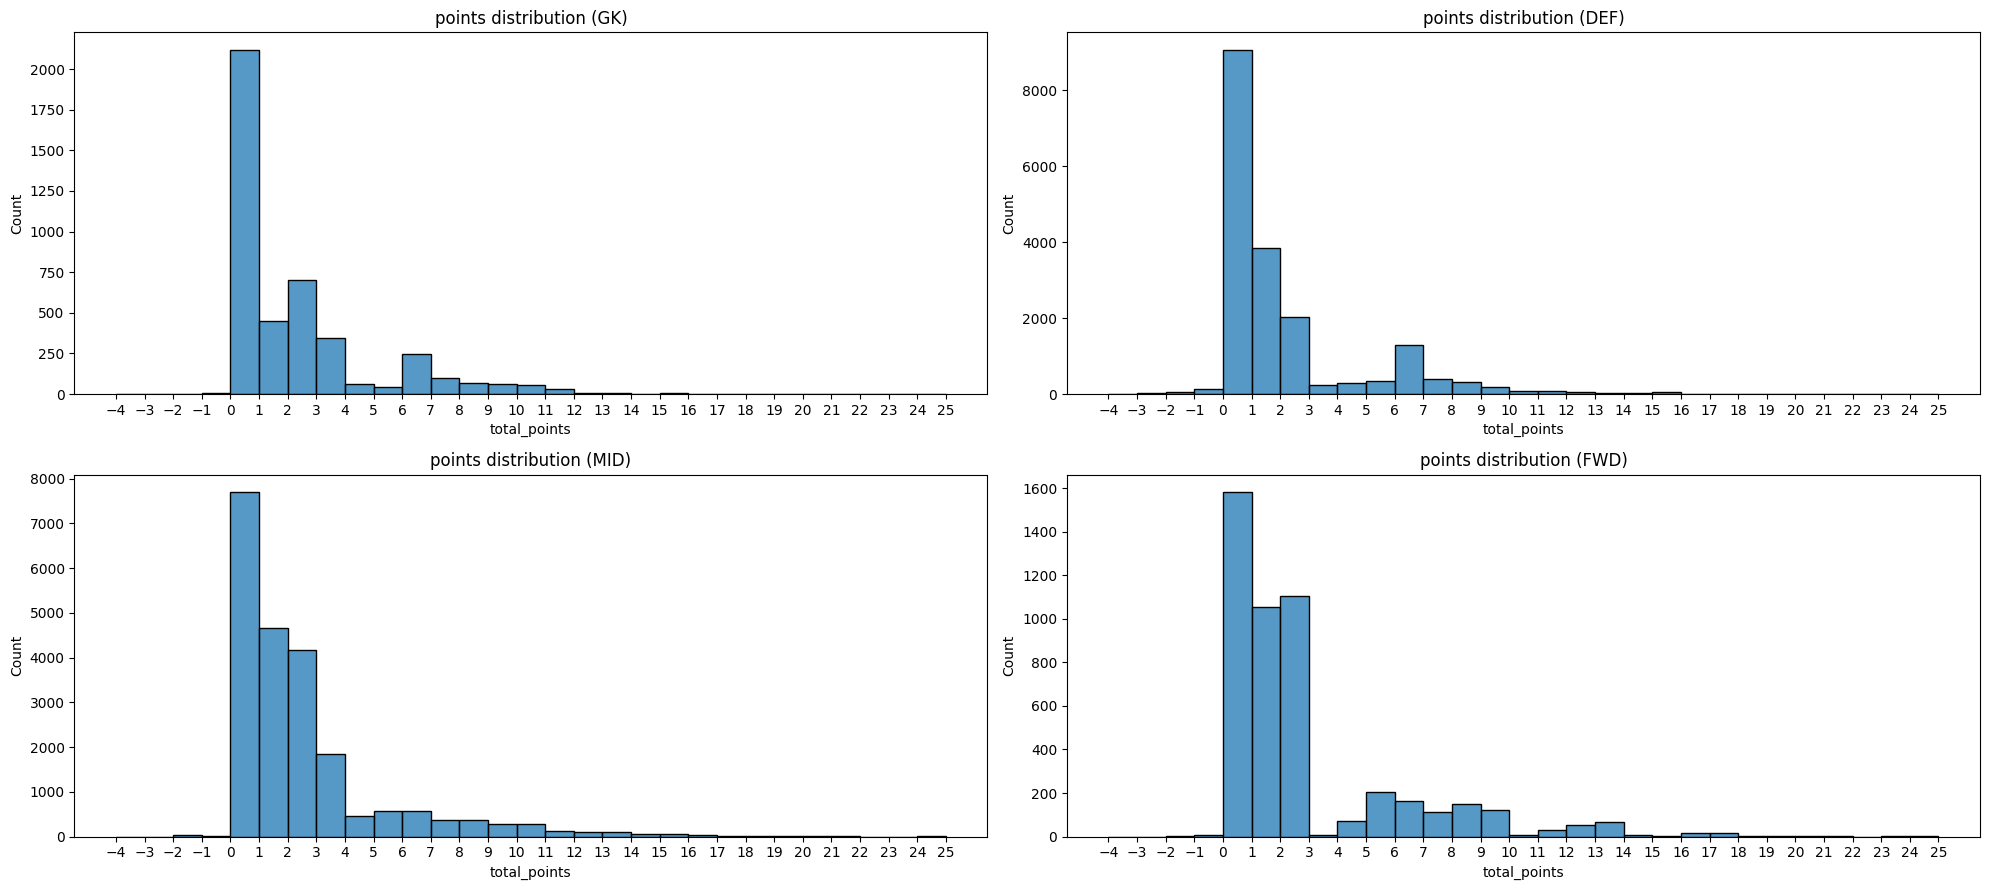

In [122]:
# Finds the minimun ammount of total points across all 4 positons
min_points = min(
    df_gk['total_points'].min(),
    df_def['total_points'].min(),
    df_mid['total_points'].min(),
    df_fwd['total_points'].min(),
)

# Finds the maximum ammount of total points across all 4 positons
max_points = max(
    df_gk['total_points'].max(),
    df_def['total_points'].max(),
    df_mid['total_points'].max(),
    df_fwd['total_points'].max(),
)

# Makes the bins the minimum and maximum amount of total points across all 4 positons
bins = np.arange(min_points,max_points)


fig, axes = plt.subplots(2, 2, figsize=(20, 9))

sns.histplot(data=df_gk, x='total_points', bins=bins, ax=axes[0, 0])
axes[0, 0].set_title('points distribution (GK)')

sns.histplot(data=df_def, x='total_points', bins=bins, ax=axes[0, 1])
axes[0, 1].set_title('points distribution (DEF)')

sns.histplot(data=df_mid, x='total_points', bins=bins, ax=axes[1, 0])
axes[1, 0].set_title('points distribution (MID)')

sns.histplot(data=df_fwd, x='total_points', bins=bins, ax=axes[1, 1])
axes[1, 1].set_title('points distribution (FWD)')

# Forces all integer on x-axis
for ax in axes.flatten():
    ax.set_xticks(range(int(min_points), int(max_points)))

plt.tight_layout()
plt.show()

# Training model (Iteration: 1)

### Train/Test split
The data was divided into an 70% training 30% testing split (Figure 6) to ensure the models were trained on a substantial portion of the data while reserving enough for evaluation

In [123]:
def training_model(position,df,features,printing = True):
    
    # Training the model with a 30% test/train split, random state set to 1111 so that this test is replicable 
    df_train, df_test = train_test_split(df[['total_points'] + features], test_size=0.3, random_state=1111)
    if printing == True:
        print(f'{position}:')
        print(f'Shape: {df.shape}')
        print(f'Train Shape: {df_train.shape}')
        print(f'Test Shape: {df_test.shape}')
        print('')

    return df_train, df_test

In [124]:
df_train_gk, df_test_gk = training_model('GK', df_gk, gk_total_features)
df_train_def, df_test_def = training_model('DEF', df_def, def_total_features)
df_train_mid, df_test_mid = training_model('MID', df_mid, mid_total_features)
df_train_fwd, df_test_fwd = training_model('FWD', df_fwd, fwd_total_features)

GK:
Shape: (4311, 18)
Train Shape: (3017, 12)
Test Shape: (1294, 12)

DEF:
Shape: (18537, 17)
Train Shape: (12975, 11)
Test Shape: (5562, 11)

MID:
Shape: (21896, 18)
Train Shape: (15327, 12)
Test Shape: (6569, 12)

FWD:
Shape: (4790, 16)
Train Shape: (3353, 10)
Test Shape: (1437, 10)



### Testing for Multicollinearity (Iteration: 1)
The visuals show that The feature previous_5_game_avg_total_points has high multicollinearity with other performance features (minutes, influence, cleans sheets, etc)

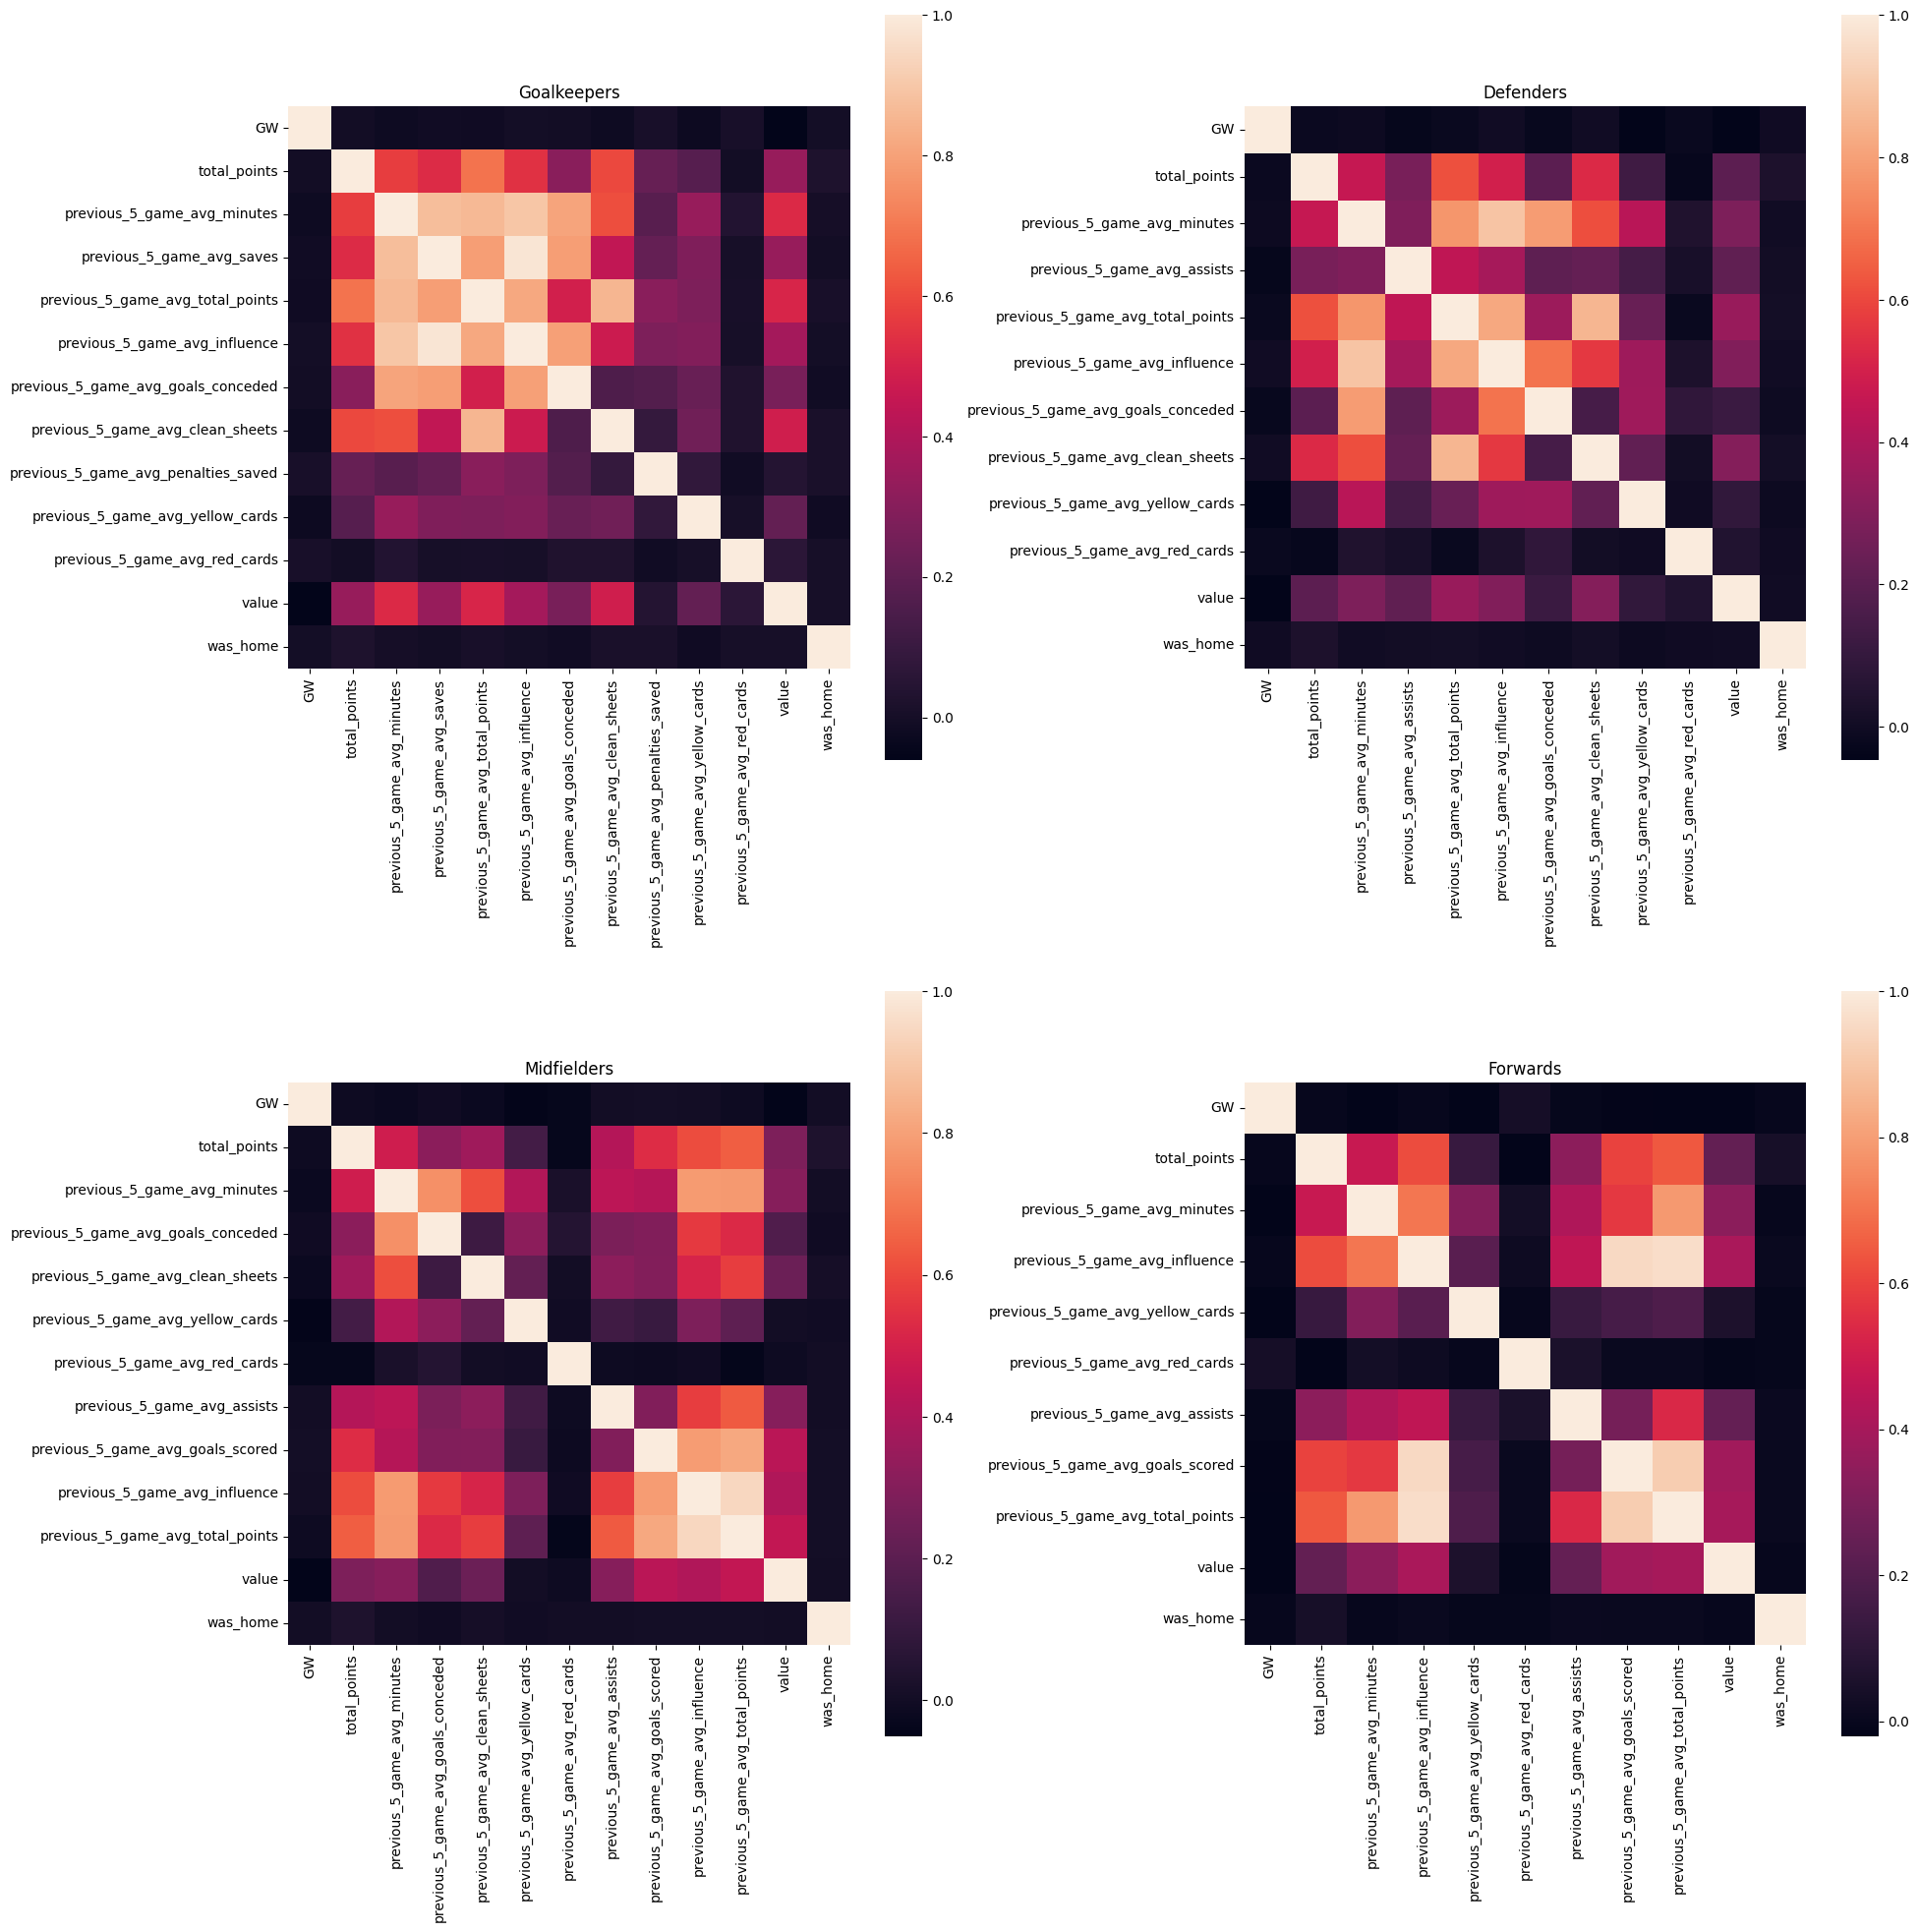

In [125]:
def combined_correlation_plot():
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))

    sns.heatmap(df_gk.corr(numeric_only=True), ax=axes[0, 0], square=True)
    axes[0, 0].set_title('Goalkeepers')

    sns.heatmap(df_def.corr(numeric_only=True), ax=axes[0, 1], square=True)
    axes[0, 1].set_title('Defenders')

    sns.heatmap(df_mid.corr(numeric_only=True), ax=axes[1, 0], square=True)
    axes[1, 0].set_title('Midfielders')

    sns.heatmap(df_fwd.corr(numeric_only=True), ax=axes[1, 1], square=True)
    axes[1, 1].set_title('Forwards')

    plt.tight_layout()
    plt.show()
combined_correlation_plot()

### Model Creation (Iteration: 1)

In [126]:
def train_and_predict(position,df_train, df_test, features, target = 'total_points',printing = True):
    
    # Train
    x_train = df_train[features]
    y_train = df_train[target]

    # Test
    x_test = df_test[features]
    y_test = df_test[target]

    # model
    model = LinearRegression()
    model.fit(x_train, y_train)

    # predict
    y_pred = model.predict(x_test)

    if printing == True:
        print(f'{position}:')
        print(f'R Squared = {model.score(x_test, y_test)}')
        print(f'Model intecept {model.intercept_}')
        display(pd.DataFrame(zip(x_train.columns, model.coef_), columns=['Variable', 'Coeff']))
        print('')

    return model, x_test, y_test, y_pred, x_train, y_train

gk_model, x_test_gk, y_test_gk, y_pred_gk, x_train_gk, y_train_gk = train_and_predict('GK',df_train_gk, df_test_gk, gk_total_features)
def_model, x_test_def, y_test_def, y_pred_def, x_train_def, y_train_def = train_and_predict('DEF', df_train_def, df_test_def, def_total_features)
mid_model, x_test_mid, y_test_mid, y_pred_mid, x_train_mid, y_train_mid = train_and_predict('MID', df_train_mid, df_test_mid, mid_total_features)
fwd_model, x_test_fwd, y_test_fwd, y_pred_fwd, x_train_fwd, y_train_fwd = train_and_predict('FWD', df_train_fwd, df_test_fwd, fwd_total_features)

GK:
R Squared = 0.4653144116948488
Model intecept 0.19095541371551406


,Variable,Coeff
0,previous_5_game_avg_minutes,-0.008596
1,previous_5_game_avg_saves,-0.150901
2,previous_5_game_avg_total_points,1.456423
3,previous_5_game_avg_influence,-0.009674
4,previous_5_game_avg_goals_conceded,0.121121
5,previous_5_game_avg_clean_sheets,-1.795498
6,previous_5_game_avg_penalties_saved,-1.429849
7,previous_5_game_avg_yellow_cards,0.327996
8,previous_5_game_avg_red_cards,-2.805926
9,value,-0.038859



DEF:
R Squared = 0.3871215699964471
Model intecept 0.3740794250196029


,Variable,Coeff
0,previous_5_game_avg_minutes,0.000424
1,previous_5_game_avg_assists,0.176481
2,previous_5_game_avg_total_points,0.953626
3,previous_5_game_avg_influence,0.000385
4,previous_5_game_avg_goals_conceded,-0.035821
5,previous_5_game_avg_clean_sheets,0.091104
6,previous_5_game_avg_yellow_cards,-0.432820
7,previous_5_game_avg_red_cards,-1.921529
8,value,-0.078715
9,was_home,0.143834



MID:
R Squared = 0.40686178821624397
Model intecept 0.018450626629571865


,Variable,Coeff
0,previous_5_game_avg_minutes,-0.008754
1,previous_5_game_avg_goals_conceded,-0.050017
2,previous_5_game_avg_clean_sheets,-0.094228
3,previous_5_game_avg_yellow_cards,0.313725
4,previous_5_game_avg_red_cards,-0.443955
5,previous_5_game_avg_assists,-0.631826
6,previous_5_game_avg_goals_scored,-1.394724
7,previous_5_game_avg_influence,0.011466
8,previous_5_game_avg_total_points,1.192950
9,value,-0.003286



FWD:
R Squared = 0.3624093146875542
Model intecept 0.2723013714464937


,Variable,Coeff
0,previous_5_game_avg_minutes,-0.012831
1,previous_5_game_avg_influence,-0.030240
2,previous_5_game_avg_yellow_cards,1.175348
3,previous_5_game_avg_red_cards,-2.232438
4,previous_5_game_avg_assists,-0.468373
5,previous_5_game_avg_goals_scored,0.002013
6,previous_5_game_avg_total_points,1.324977
7,value,-0.053691
8,was_home,0.211948


### R Squared 
The R Squared = 0.465 this indicates that the GK Model explains 46.5% of the variance in the outcome. Therefore the model has an adequate predictive power.

###  Model intecept
The Model intecept = 0.191 this is the baseline for the model before total_points is adjusted by the features

In [127]:
def model_metrics(y_test,y_pred):
    r2_score = round(met.r2_score(y_test, y_pred),3)
    mae = round(met.mean_absolute_error(y_test, y_pred),3)
    rmse = float(format(np.sqrt(met.mean_squared_error(y_test,y_pred)),'.3f'))
    return r2_score, mae, rmse

def model_results_table():
    model_results = pd.DataFrame({
        'position Model': ['GK','DEF','MID','FWD'],
        'R2 Score': [gk_r2_score,def_r2_score,mid_r2_score,fwd_r2_score],
        'Intercept': [round(gk_model.intercept_,3), round(def_model.intercept_,3), round(mid_model.intercept_,3), round(fwd_model.intercept_,3)],
        'MAE': [gk_mae, def_mae, mid_mae, fwd_mae],
        'RMSE': [gk_rmse, def_rmse, mid_rmse, fwd_rmse]})
    return model_results


gk_r2_score,gk_mae,gk_rmse = model_metrics(y_test_gk,y_pred_gk)
def_r2_score,def_mae,def_rmse = model_metrics(y_test_def,y_pred_def)
mid_r2_score,mid_mae,mid_rmse = model_metrics(y_test_mid,y_pred_mid)
fwd_r2_score,fwd_mae,fwd_rmse = model_metrics(y_test_fwd,y_pred_fwd)

model_results_table()


,position Model,R2 Score,Intercept,MAE,RMSE
0,GK,0.465,0.191,1.170,1.864
1,DEF,0.387,0.374,1.356,2.165
2,MID,0.407,0.018,1.369,2.247
3,FWD,0.362,0.272,1.655,2.482


In [128]:
def postional_model_fit():
    for model_name, features, df in [
        ('GK model fit', gk_total_features, df_train_gk),
        ('DEF model fit', def_total_features, df_train_def),
        ('MID model fit', mid_total_features, df_train_mid),
        ('FWD model fit', fwd_total_features, df_train_fwd)]:
              
            formula = f'total_points ~ {" + ".join(features)}'
            model = smf.ols(formula=formula, data=df).fit()

            print(model_name)
            print(model.summary())
            print('')
postional_model_fit()

GK model fit
                            OLS Regression Results                            
Dep. Variable:           total_points   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     249.0
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        16:36:27   Log-Likelihood:                -6286.2
No. Observations:                3017   AIC:                         1.260e+04
Df Residuals:                    3005   BIC:                         1.267e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

# Creating Model (Iteration 2)

## Removing unneeded variables
The feature previous_5_game_avg_total_points has high multicollinearity with other performance features (minutes, influence, cleans sheets, etc) the correlation levels indicate there is a substantial overlap between these features. Additionally it has a very high t-value (10.284 for GK model) across all models which inflates it's statistical dominance whilst suppressing the importance of other features; this is likely due to it being derived from the target variable (total_points).Therefore previous_5_game_avg_total_points was removed from all the models as including it would cause the model to be unstable and reduced interpretability of other predictors.

In [129]:
for list in [gk_total_features,gk_features, def_total_features,def_features, mid_total_features, mid_features, fwd_total_features, fwd_features]:
    list.remove('previous_5_game_avg_total_points')


for df in [df_gk, df_def, df_mid, df_fwd]:
    df.drop('previous_5_game_avg_total_points',axis='columns', inplace= True)

In [130]:
df_train_gk, df_test_gk = training_model('GK', df_gk, gk_total_features)
df_train_def, df_test_def = training_model('DEF', df_def, def_total_features)
df_train_mid, df_test_mid = training_model('MID', df_mid, mid_total_features)
df_train_fwd, df_test_fwd = training_model('FWD', df_fwd, fwd_total_features)

GK:
Shape: (4311, 17)
Train Shape: (3017, 11)
Test Shape: (1294, 11)

DEF:
Shape: (18537, 16)
Train Shape: (12975, 10)
Test Shape: (5562, 10)

MID:
Shape: (21896, 17)
Train Shape: (15327, 11)
Test Shape: (6569, 11)

FWD:
Shape: (4790, 15)
Train Shape: (3353, 9)
Test Shape: (1437, 9)



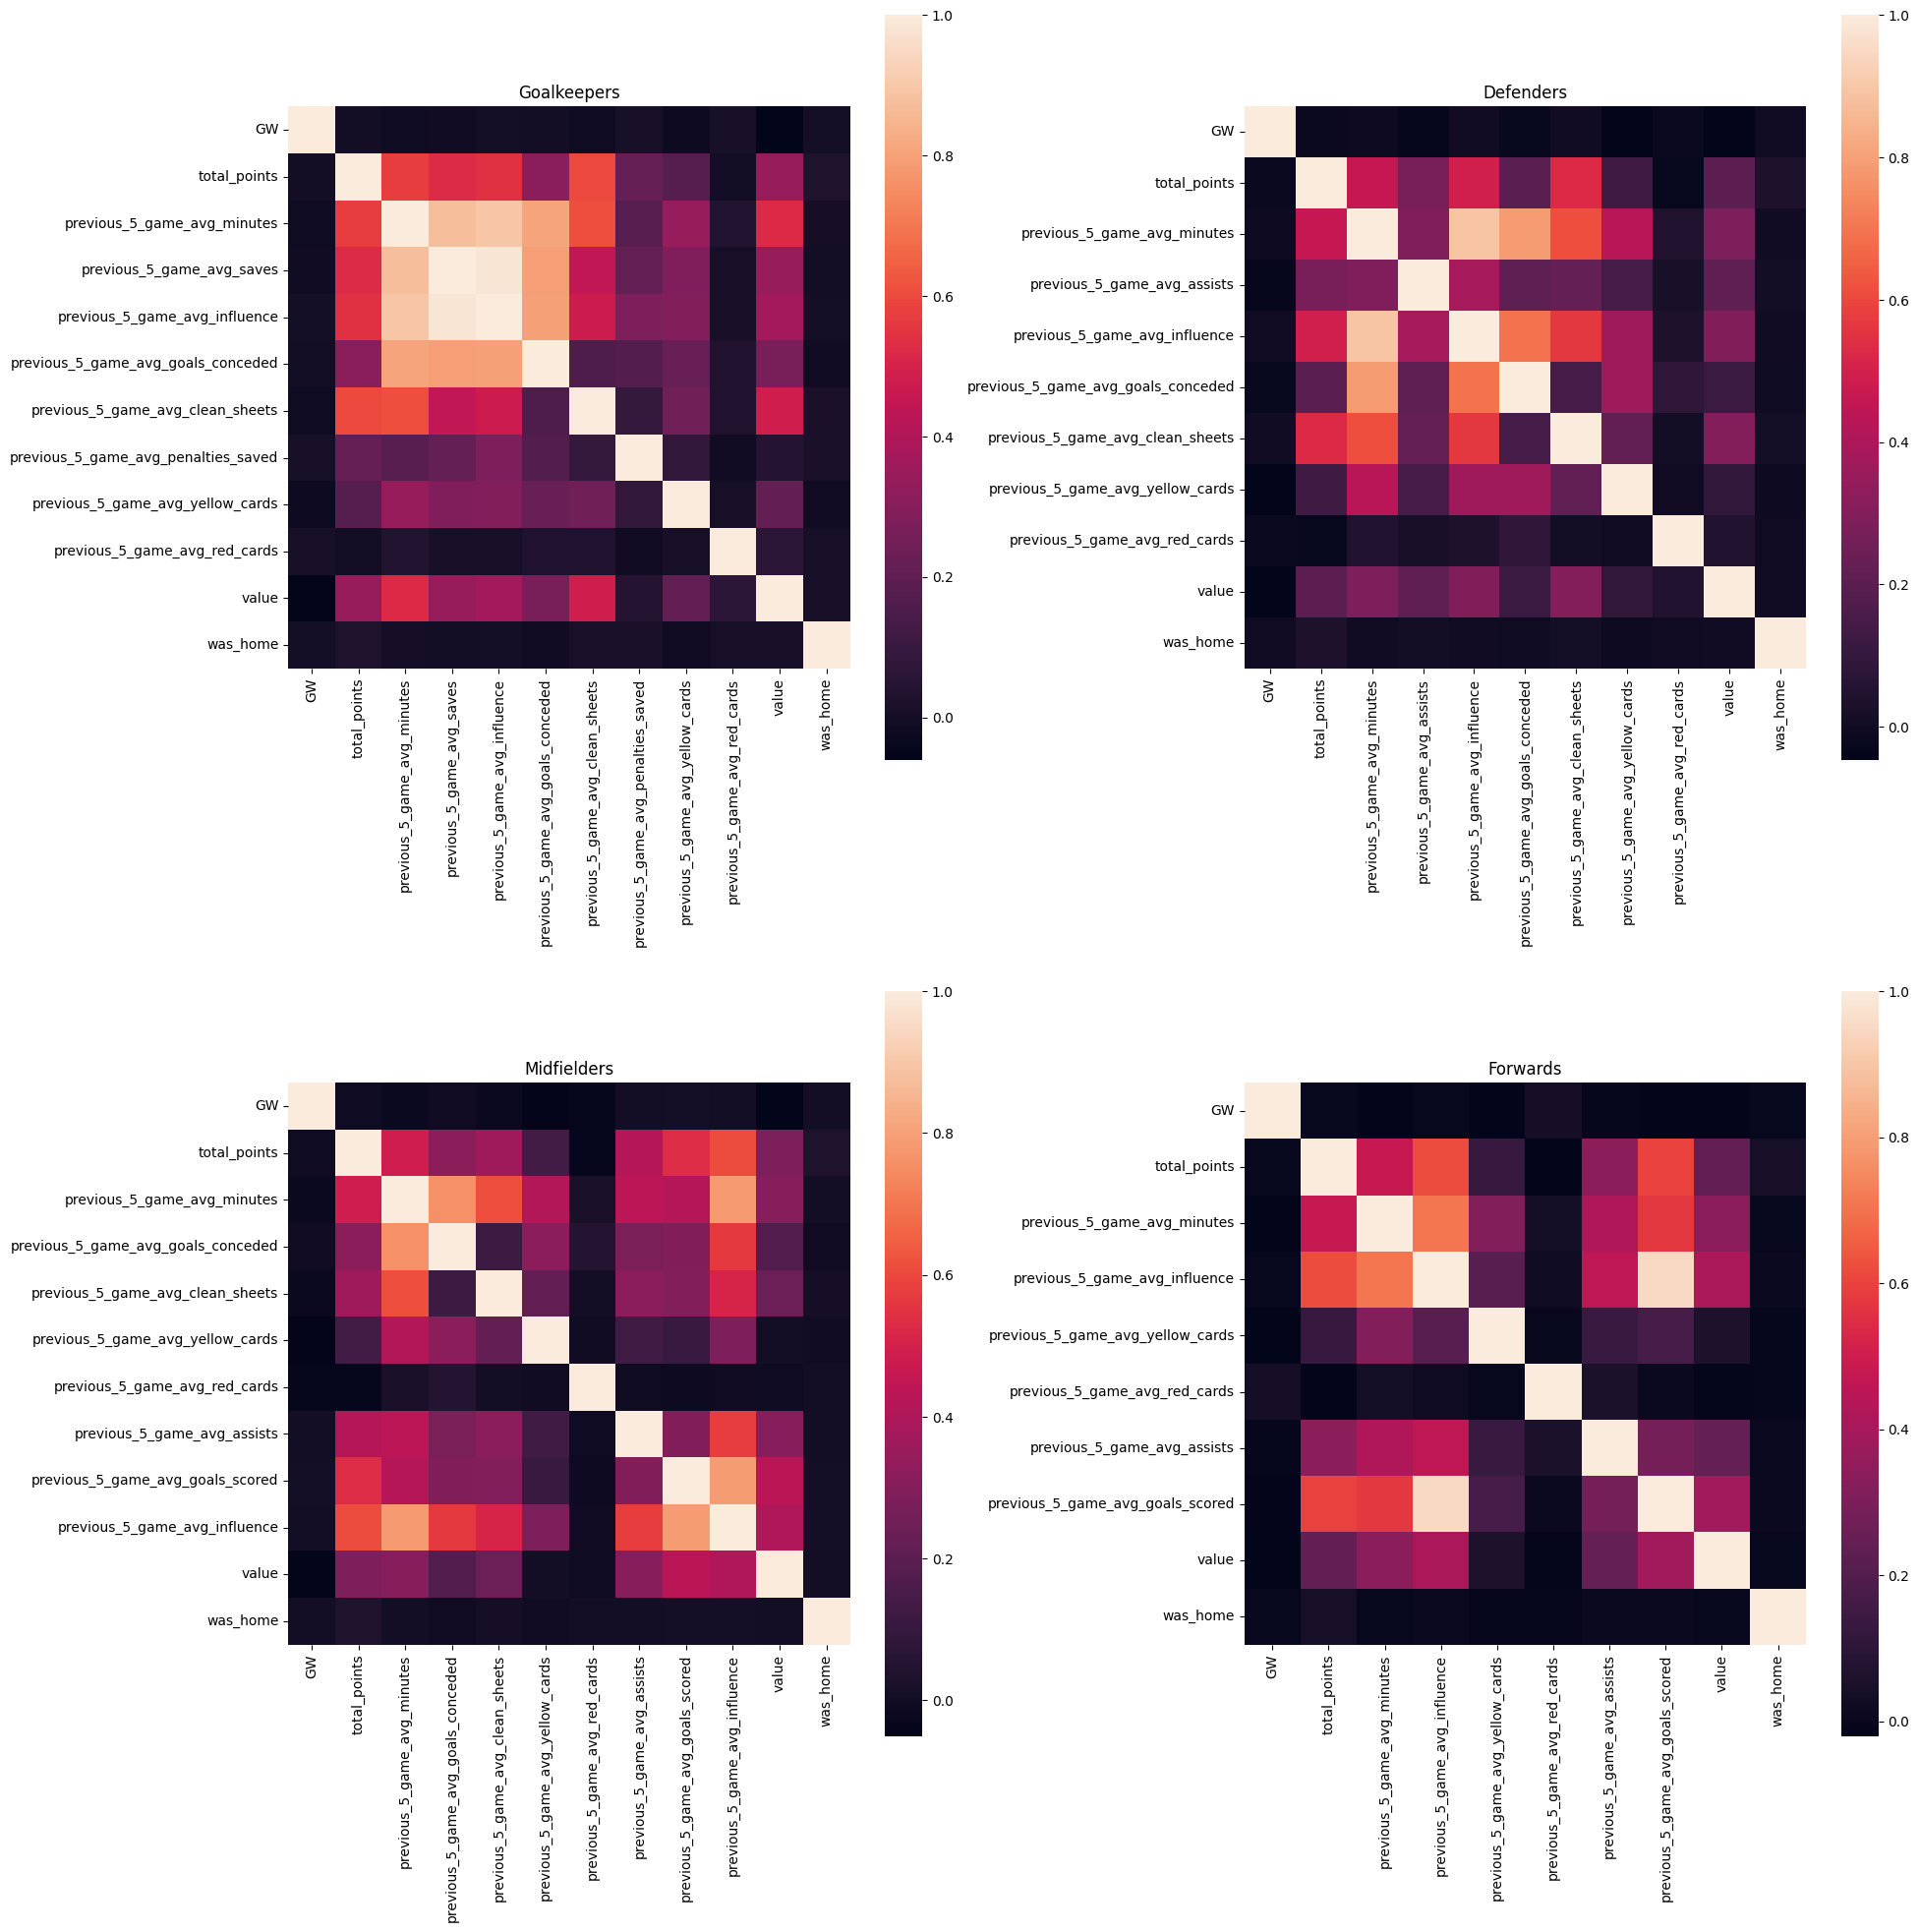

In [131]:
combined_correlation_plot()

### Remaking the models without the unneeded variables

In [132]:
gk_model, x_test_gk, y_test_gk, y_pred_gk, x_train_gk, y_train_gk = train_and_predict('GK',df_train_gk, df_test_gk, gk_total_features)
def_model, x_test_def, y_test_def, y_pred_def, x_train_def, y_train_def = train_and_predict('DEF', df_train_def, df_test_def, def_total_features)
mid_model, x_test_mid, y_test_mid, y_pred_mid, x_train_mid, y_train_mid = train_and_predict('MID', df_train_mid, df_test_mid, mid_total_features)
fwd_model, x_test_fwd, y_test_fwd, y_pred_fwd, x_train_fwd, y_train_fwd = train_and_predict('FWD', df_train_fwd, df_test_fwd, fwd_total_features)


GK:
R Squared = 0.4729360109655999
Model intecept 0.2844868904408935


,Variable,Coeff
0,previous_5_game_avg_minutes,0.019598
1,previous_5_game_avg_saves,0.367121
2,previous_5_game_avg_influence,0.016451
3,previous_5_game_avg_goals_conceded,-0.765008
4,previous_5_game_avg_clean_sheets,4.493344
5,previous_5_game_avg_penalties_saved,6.518397
6,previous_5_game_avg_yellow_cards,-0.947600
7,previous_5_game_avg_red_cards,-6.536558
8,value,-0.060014
9,was_home,0.139724



DEF:
R Squared = 0.35815306577513506
Model intecept 0.309530989306519


,Variable,Coeff
0,previous_5_game_avg_minutes,0.010136
1,previous_5_game_avg_assists,2.624532
2,previous_5_game_avg_influence,0.087987
3,previous_5_game_avg_goals_conceded,-0.529302
4,previous_5_game_avg_clean_sheets,4.223909
5,previous_5_game_avg_yellow_cards,-1.373521
6,previous_5_game_avg_red_cards,-4.003450
7,value,-0.043849
8,was_home,0.149892



MID:
R Squared = 0.3951015683105845
Model intecept 0.30399220834299867


,Variable,Coeff
0,previous_5_game_avg_minutes,0.015797
1,previous_5_game_avg_goals_conceded,-0.067750
2,previous_5_game_avg_clean_sheets,1.074204
3,previous_5_game_avg_yellow_cards,-0.850502
4,previous_5_game_avg_red_cards,-4.322374
5,previous_5_game_avg_assists,3.092772
6,previous_5_game_avg_goals_scored,5.088612
7,previous_5_game_avg_influence,0.038749
8,value,-0.021610
9,was_home,0.163422



FWD:
R Squared = 0.3502521505631446
Model intecept 0.8091103270417159


,Variable,Coeff
0,previous_5_game_avg_minutes,0.016078
1,previous_5_game_avg_influence,-0.013456
2,previous_5_game_avg_yellow_cards,-0.222950
3,previous_5_game_avg_red_cards,-6.792079
4,previous_5_game_avg_assists,3.748001
5,previous_5_game_avg_goals_scored,6.507159
6,value,-0.098053
7,was_home,0.213240


In [133]:
gk_r2_score,gk_mae,gk_rmse = model_metrics(y_test_gk,y_pred_gk)
def_r2_score,def_mae,def_rmse = model_metrics(y_test_def,y_pred_def)
mid_r2_score,mid_mae,mid_rmse = model_metrics(y_test_mid,y_pred_mid)
fwd_r2_score,fwd_mae,fwd_rmse = model_metrics(y_test_fwd,y_pred_fwd)

# Results table
model_results_table()

,position Model,R2 Score,Intercept,MAE,RMSE
0,GK,0.473,0.284,1.145,1.851
1,DEF,0.358,0.310,1.398,2.216
2,MID,0.395,0.304,1.414,2.269
3,FWD,0.350,0.809,1.698,2.506


## Hypothesis testing

### GK

|Hypothesis| Variable                      | P-value |Outcome|
|----------|-------------------------------|---------|------------------------------------------------------|
|$H_1$| previous_5_game_avg_minutes        | 0.000   |Fail to reject Null Hypothesis (P-value > 0.05 )|
|$H_2$| previous_5_game_avg_saves             | 0.005   |Reject Null Hypothesis (P-value < 0.05)|
|$H_3$| previous_5_game_avg_influence         | 0.373   |Fail to reject Null Hypothesis (P-value > 0.05 )|
|$H_4$| previous_5_game_avg_goals_conceded    | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_5$| previous_5_game_avg_clean_sheets      | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_6$| previous_5_game_avg_penalties_saved   | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_7$| previous_5_game_avg_yellow_cards      | 0.023   |Reject Null Hypothesis (P-value < 0.05)|
|$H_8$| previous_5_game_avg_red_cards         | 0.018   |Reject Null Hypothesis (P-value < 0.05)|
|$H_9$| value                                 | 0.513   |Fail to reject Null Hypothesis (P-value > 0.05 )|
|$H_{10}$| was_home                             | 0.053  |Although the P-value > 0.05 it is on the borderline, removing other variables might effect the P-value therefore it will be tested again in the next iteration |

### DEF
|Hypothesis| Variable                              | P-value |Outcome|
|----------|---------------------------------------|---------|------------------------------------------------------|
|$H_1$| previous_5_game_avg_minutes           | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_2$| previous_5_game_avg_assists           | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_3$| previous_5_game_avg_influence         | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_4$| previous_5_game_avg_goals_conceded    | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_5$| previous_5_game_avg_clean_sheets      | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_6$| previous_5_game_avg_yellow_cards      | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_7$| previous_5_game_avg_red_cards         | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_8$| value                                | 0.227   |Fail to reject Null Hypothesis (P-value > 0.05 )|
|$H_9$| was_home                             | 0.000   |Reject Null Hypothesis (P-value < 0.05)|

### MID
|Hypothesis| Variable                              | P-value |Outcome|
|----------|---------------------------------------|---------|------------------------------------------------------|
|$H_1$| previous_5_game_avg_minutes           | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_2$| previous_5_game_avg_goals_conceded    | 0.258   |Fail to reject Null Hypothesis (P-value > 0.05 )|
|$H_3$| previous_5_game_avg_clean_sheets      | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_4$| previous_5_game_avg_yellow_cards      | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_5$| previous_5_game_avg_red_cards         | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_6$| previous_5_game_avg_assists           | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_7$| previous_5_game_avg_goals_scored      | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_8$| previous_5_game_avg_influence         | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_9$| value                                | 0.168   |Fail to reject Null Hypothesis (P-value > 0.05 )|
|$H_{10}$| was_home                             | 0.000   |Reject Null Hypothesis (P-value < 0.05)|

### FWD
|Hypothesis| Variable                              | P-value |Outcome|
|----------|---------------------------------------|---------|------------------------------------------------------|
|$H_1$| previous_5_game_avg_minutes           | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_2$| previous_5_game_avg_influence         | 0.482   |Fail to reject Null Hypothesis (P-value > 0.05 )|
|$H_3$| previous_5_game_avg_yellow_cards      | 0.557   |Fail to reject Null Hypothesis (P-value > 0.05 )|
|$H_4$| previous_5_game_avg_red_cards         | 0.019   |Reject Null Hypothesis (P-value < 0.05)|
|$H_5$| previous_5_game_avg_assists           | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_6$| previous_5_game_avg_goals_scored      | 0.000   |Reject Null Hypothesis (P-value < 0.05)|
|$H_7$| value                                | 0.001   |Reject Null Hypothesis (P-value < 0.05)|
|$H_8$| was_home                             | 0.019   |Reject Null Hypothesis (P-value < 0.05)|

In [134]:
postional_model_fit()

GK model fit
                            OLS Regression Results                            
Dep. Variable:           total_points   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     254.4
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        16:36:29   Log-Likelihood:                -6338.4
No. Observations:                3017   AIC:                         1.270e+04
Df Residuals:                    3006   BIC:                         1.276e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [135]:
def variable_removal(df, total_feature, features):
    for variable in features:
        total_feature.remove(variable)
        df.drop(variable,axis='columns', inplace= True)


variable_removal(df_gk, gk_total_features, ['previous_5_game_avg_influence','value'])
variable_removal(df_def,def_total_features, ['value'])
variable_removal(df_mid,mid_total_features, ['previous_5_game_avg_goals_conceded','value'])
variable_removal(df_fwd,fwd_total_features, ['previous_5_game_avg_influence','previous_5_game_avg_yellow_cards'])

## Model Iteration 3

In [136]:
df_train_gk, df_test_gk = training_model('GK', df_gk, gk_total_features)
df_train_def, df_test_def = training_model('DEF', df_def, def_total_features)
df_train_mid, df_test_mid = training_model('MID', df_mid, mid_total_features)
df_train_fwd, df_test_fwd = training_model('FWD', df_fwd, fwd_total_features)

GK:
Shape: (4311, 15)
Train Shape: (3017, 9)
Test Shape: (1294, 9)

DEF:
Shape: (18537, 15)
Train Shape: (12975, 9)
Test Shape: (5562, 9)

MID:
Shape: (21896, 15)
Train Shape: (15327, 9)
Test Shape: (6569, 9)

FWD:
Shape: (4790, 13)
Train Shape: (3353, 7)
Test Shape: (1437, 7)



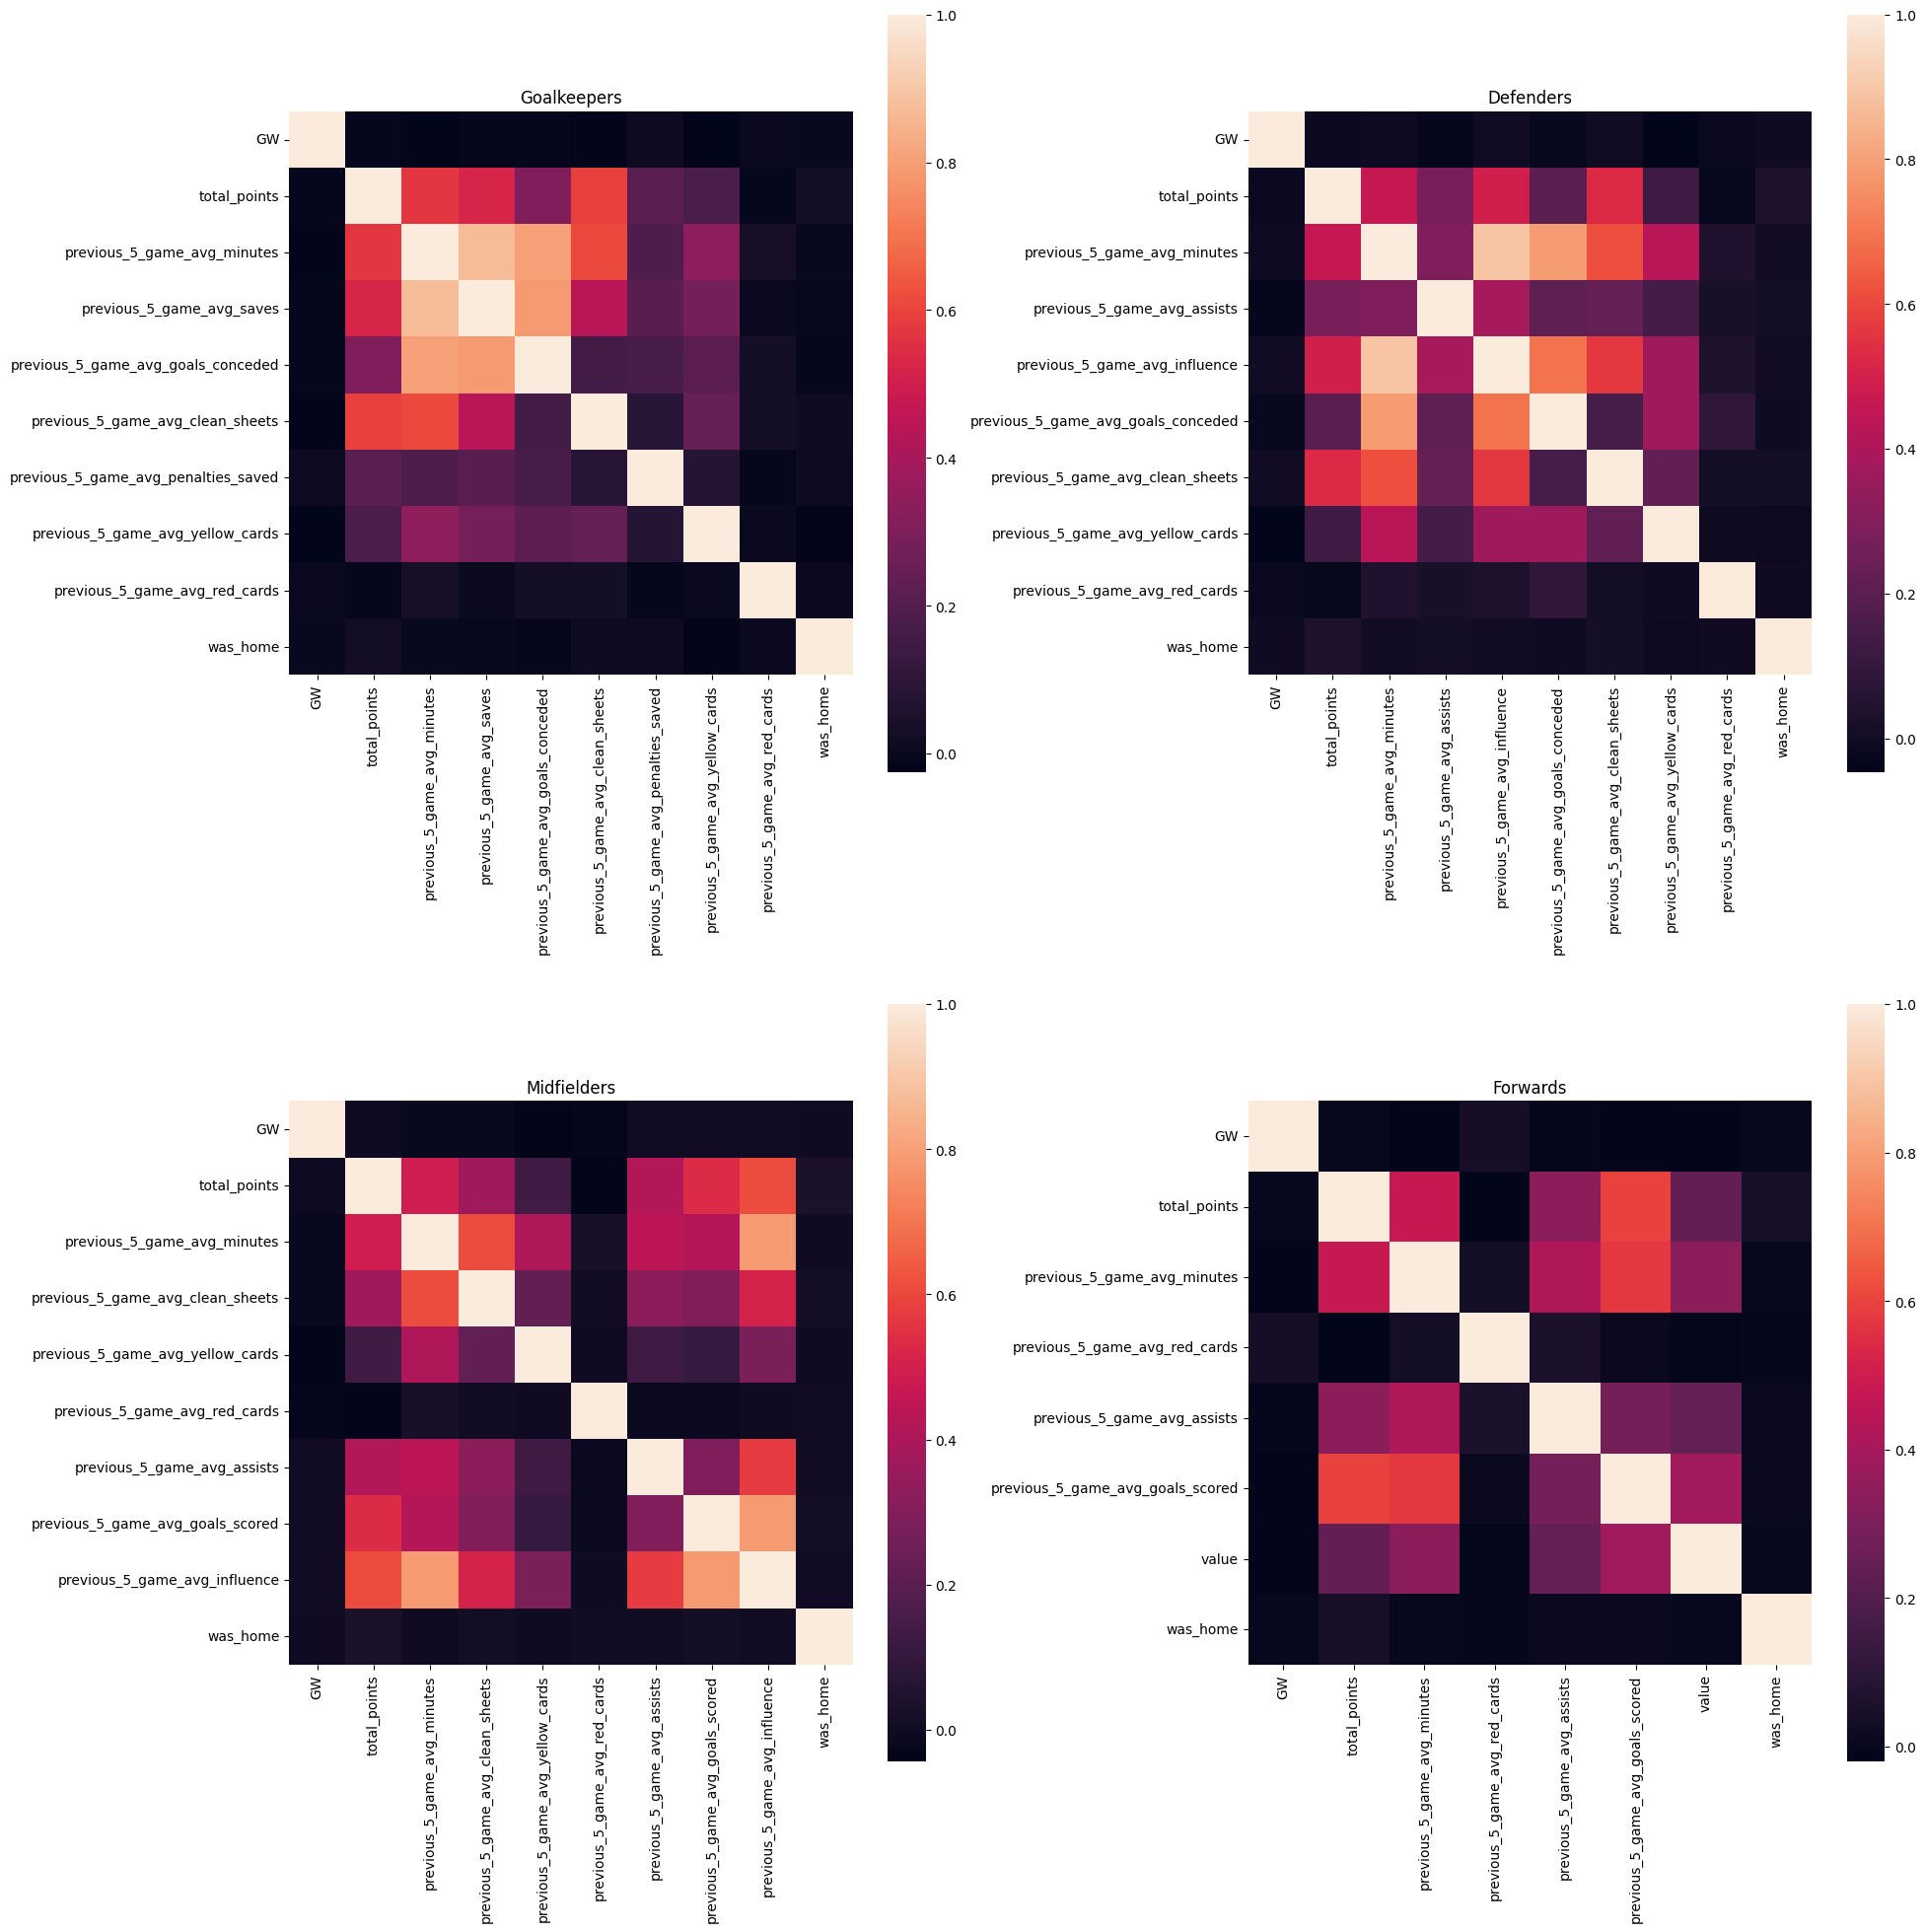

In [137]:
combined_correlation_plot()

In [138]:
gk_model, x_test_gk, y_test_gk, y_pred_gk, x_train_gk, y_train_gk = train_and_predict('GK',df_train_gk, df_test_gk, gk_total_features)
def_model, x_test_def, y_test_def, y_pred_def, x_train_def, y_train_def = train_and_predict('DEF', df_train_def, df_test_def, def_total_features)
mid_model, x_test_mid, y_test_mid, y_pred_mid, x_train_mid, y_train_mid = train_and_predict('MID', df_train_mid, df_test_mid, mid_total_features)
fwd_model, x_test_fwd, y_test_fwd, y_pred_fwd, x_train_fwd, y_train_fwd = train_and_predict('FWD', df_train_fwd, df_test_fwd, fwd_total_features)

GK:
R Squared = 0.4731326572894189
Model intecept 0.026661769952432746


,Variable,Coeff
0,previous_5_game_avg_minutes,0.019555
1,previous_5_game_avg_saves,0.479836
2,previous_5_game_avg_goals_conceded,-0.752239
3,previous_5_game_avg_clean_sheets,4.495528
4,previous_5_game_avg_penalties_saved,6.832705
5,previous_5_game_avg_yellow_cards,-0.959233
6,previous_5_game_avg_red_cards,-6.724190
7,was_home,0.140614



DEF:
R Squared = 0.3581466956214774
Model intecept 0.11502288201039845


,Variable,Coeff
0,previous_5_game_avg_minutes,0.009909
1,previous_5_game_avg_assists,2.591855
2,previous_5_game_avg_influence,0.087692
3,previous_5_game_avg_goals_conceded,-0.520000
4,previous_5_game_avg_clean_sheets,4.216042
5,previous_5_game_avg_yellow_cards,-1.367748
6,previous_5_game_avg_red_cards,-4.046096
7,was_home,0.150361



MID:
R Squared = 0.3945476403209668
Model intecept 0.19252341561950237


,Variable,Coeff
0,previous_5_game_avg_minutes,0.014095
1,previous_5_game_avg_clean_sheets,1.192405
2,previous_5_game_avg_yellow_cards,-0.825055
3,previous_5_game_avg_red_cards,-4.371410
4,previous_5_game_avg_assists,3.059245
5,previous_5_game_avg_goals_scored,5.001898
6,previous_5_game_avg_influence,0.039796
7,was_home,0.163626



FWD:
R Squared = 0.35003518588048044
Model intecept 0.8007691866296887


,Variable,Coeff
0,previous_5_game_avg_minutes,0.014899
1,previous_5_game_avg_red_cards,-6.701659
2,previous_5_game_avg_assists,3.579926
3,previous_5_game_avg_goals_scored,6.078514
4,value,-0.097413
5,was_home,0.214464


In [139]:
gk_r2_score,gk_mae,gk_rmse = model_metrics(y_test_gk,y_pred_gk)
def_r2_score,def_mae,def_rmse = model_metrics(y_test_def,y_pred_def)
mid_r2_score,mid_mae,mid_rmse = model_metrics(y_test_mid,y_pred_mid)
fwd_r2_score,fwd_mae,fwd_rmse = model_metrics(y_test_fwd,y_pred_fwd)

# Results table
model_results_table()

,position Model,R2 Score,Intercept,MAE,RMSE
0,GK,0.473,0.027,1.145,1.850
1,DEF,0.358,0.115,1.398,2.216
2,MID,0.395,0.193,1.414,2.270
3,FWD,0.350,0.801,1.698,2.506


In [140]:
postional_model_fit()

GK model fit
                            OLS Regression Results                            
Dep. Variable:           total_points   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     317.9
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        16:36:30   Log-Likelihood:                -6339.0
No. Observations:                3017   AIC:                         1.270e+04
Df Residuals:                    3008   BIC:                         1.275e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

# Using Iteration 1
Although some features in i1 have p-values > 0.05, i1 provides better forecasting than i2 and i3 in three of the four positional models. Higher R² values indicate that i1 explains a greater proportion of the variability in total score, whereas lower MAE and RMSE values indicate smaller average prediction errors. Therefore, although a p-value-based backward elimination approach (i3) was evaluated, it did not improve predictive performance compared to the full model (i1).

In [141]:
# Changing the features back to the ones used in iteration 1
gk_total_features = gk_total_features_original.copy()
gk_features = gk_features_original.copy()
df_gk = df_gk_original.copy()

def_total_features = def_total_features_original.copy()
def_features = def_features_original.copy()
df_def = df_def_original.copy()

mid_total_features = mid_total_features_original.copy()
mid_features = mid_features_original.copy()
df_mid = df_mid_original.copy()

fwd_total_features = fwd_total_features_original.copy()
fwd_features = fwd_features_original.copy()
df_fwd = df_fwd_original.copy()

# Splitting into iteration 1's train/test split 
df_train_gk, df_test_gk = training_model('GK', df_gk, gk_total_features, printing = False)
df_train_def, df_test_def = training_model('DEF', df_def, def_total_features, printing = False)
df_train_mid, df_test_mid = training_model('MID', df_mid, mid_total_features, printing = False)
df_train_fwd, df_test_fwd = training_model('FWD', df_fwd, fwd_total_features, printing = False)

# remaking the model for iteration 1
gk_model, x_test_gk, y_test_gk, y_pred_gk, x_train_gk, y_train_gk = train_and_predict('GK',df_train_gk, df_test_gk, gk_total_features, printing = False)
def_model, x_test_def, y_test_def, y_pred_def, x_train_def, y_train_def = train_and_predict('DEF', df_train_def, df_test_def, def_total_features, printing = False)
mid_model, x_test_mid, y_test_mid, y_pred_mid, x_train_mid, y_train_mid = train_and_predict('MID', df_train_mid, df_test_mid, mid_total_features, printing = False)
fwd_model, x_test_fwd, y_test_fwd, y_pred_fwd, x_train_fwd, y_train_fwd = train_and_predict('FWD', df_train_fwd, df_test_fwd, fwd_total_features, printing = False)

# Creating future fixtures dataset

**Players** <br>
The dataset is filtered to only include Players currently playing in this seasons FPL game

**Fixtures** <br> 
A fixtures dataset is created containing the future gameweek fixtures with each team represented by their ID

**Team** <br> 
A Teams dataset is created that contains the team ID and it's corresponding team name

**Combining the datasets** <br>
The Team ID in the future fixtures dataset is replaced by the corresponding team name, the script then uses this data to determin whether a player is home or away in each of the future GWs

### Players

In [142]:
df_current_players  = combined_df[(combined_df['season'] == '25/26')]

df_current_players = df_current_players.sort_values('GW')

df_current_players_full = df_current_players.copy()

df_current_players = df_current_players.drop_duplicates(subset='name', keep='last')


df_current_players

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,...,mng_draw,mng_goals_scored,mng_loss,mng_underdog_draw,mng_underdog_win,mng_win,modified,defensive_contribution,gw_season,previous_5_game_avg_minutes
65696,Igor Jesus Maciel da Cruz,0,NaN,NaN,NaN,0,2,0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,2.0,season_25/26_gw_24,76.6
65691,Ashley Barnes,0,NaN,NaN,NaN,0,0,0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0,season_25/26_gw_24,0.0
65690,Tariq Lamptey,0,NaN,NaN,NaN,0,0,0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0,season_25/26_gw_24,0.0
65689,Bart Verbruggen,0,NaN,NaN,NaN,0,15,0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0,season_25/26_gw_24,90.0
65688,Pau Torres,0,NaN,NaN,NaN,0,15,0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,3.0,season_25/26_gw_24,50.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65730,Sander Berge,0,NaN,NaN,NaN,0,19,0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,8.0,season_25/26_gw_24,75.2
65703,Fabian SchÃ¤r,0,NaN,NaN,NaN,0,0,0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0,season_25/26_gw_24,33.0
65751,RaÃºl JimÃ©nez RodrÃ­guez,0,NaN,NaN,NaN,0,19,0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,6.0,season_25/26_gw_24,88.2
65752,Brian Brobbey,0,NaN,NaN,NaN,0,3,1,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,2.0,season_25/26_gw_24,86.4


### Fixtures
ingesting the future fixtures 

In [143]:
fixtures_df = pd.read_csv('C:/Users/lallen1/OneDrive - Thames Water Utilities Limited/Work/Personal/Apprenticeship/Year 1/Term 3 - Data Science Professional Practice/Formative/FPL_player_points_prediction/fixtures.csv')
fixtures_df

,code,event,finished,finished_provisional,id,kickoff_time,minutes,provisional_start_time,started,team_a,team_a_score,team_h,team_h_score,stats,team_h_difficulty,team_a_difficulty,pulse_id
0,2562201,NaN,False,False,307,NaN,0,False,NaN,8,NaN,13,NaN,[],3,5,125097
1,2561895,1.0,True,True,1,2025-08-15T19:00:00Z,90,False,True,4,2.0,12,4.0,"[{'identifier': 'goals_scored', 'a': [{'value'...",3,4,124791
2,2561896,1.0,True,True,2,2025-08-16T11:30:00Z,90,False,True,15,0.0,2,0.0,"[{'identifier': 'goals_scored', 'a': [], 'h': ...",3,4,124792
3,2561897,1.0,True,True,3,2025-08-16T14:00:00Z,90,False,True,10,1.0,6,1.0,"[{'identifier': 'goals_scored', 'a': [{'value'...",2,3,124793
4,2561900,1.0,True,True,6,2025-08-16T14:00:00Z,90,False,True,3,0.0,18,3.0,"[{'identifier': 'goals_scored', 'a': [], 'h': ...",1,3,124796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,2562270,38.0,False,False,376,2026-05-24T15:00:00Z,0,False,False,2,NaN,13,NaN,[],3,5,125166
376,2562271,38.0,False,False,377,2026-05-24T15:00:00Z,0,False,False,4,NaN,16,NaN,[],3,3,125167
377,2562273,38.0,False,False,379,2026-05-24T15:00:00Z,0,False,False,9,NaN,18,NaN,[],3,3,125169
378,2562272,38.0,False,False,378,2026-05-24T15:00:00Z,0,False,False,7,NaN,17,NaN,[],3,4,125168


In [144]:
fixtures_df.rename(columns={'event':'GW'},inplace= True)
future_fixtures_df  = fixtures_df[(fixtures_df['GW'] > 24) ]
future_fixtures_df = future_fixtures_df[[
    'GW',
    'team_a',
    'team_h'
]]
future_fixtures_df

,GW,team_a,team_h
241,25.0,16,11
242,25.0,18,14
243,25.0,17,1
244,25.0,2,4
245,25.0,19,3
...,...,...,...
375,38.0,2,13
376,38.0,4,16
377,38.0,9,18
378,38.0,7,17


### Teams
Finding the unique ID for each team

In [145]:
teams_df = pd.read_csv('C:/Users/lallen1/OneDrive - Thames Water Utilities Limited/Work/Personal/Apprenticeship/Year 1/Term 3 - Data Science Professional Practice/Formative/FPL_player_points_prediction/teams.csv')

teams_df = teams_df[[
    'id',
    'name'
]]
teams_df

,id,name
0,1,Arsenal
1,2,Aston Villa
2,3,Burnley
3,4,Bournemouth
4,5,Brentford
5,6,Brighton
6,7,Chelsea
7,8,Crystal Palace
8,9,Everton
9,10,Fulham


### Combines Future fixtures and teams datasets
Replaces ID in future fixtures with the team name

In [146]:
id_to_name = teams_df.set_index('id')['name']
future_fixtures_df['team_a'] = future_fixtures_df['team_a'].map(id_to_name)
future_fixtures_df['team_h'] = future_fixtures_df['team_h'].map(id_to_name)
future_fixtures_df

,GW,team_a,team_h
241,25.0,Nott'm Forest,Leeds
242,25.0,Spurs,Man Utd
243,25.0,Sunderland,Arsenal
244,25.0,Aston Villa,Bournemouth
245,25.0,West Ham,Burnley
...,...,...,...
375,38.0,Aston Villa,Man City
376,38.0,Bournemouth,Nott'm Forest
377,38.0,Everton,Spurs
378,38.0,Chelsea,Sunderland


In [147]:
# Home players
home_players = df_current_players.merge(
    future_fixtures_df,
    left_on='team',
    right_on='team_h'
)

home_players['was_home'] = 1

# Away players
away_players = df_current_players.merge(
    future_fixtures_df,
    left_on='team',
    right_on='team_a'
)

away_players['was_home'] = 0


## Gets the latest fixture 
# Combine
players_future_gw = pd.concat([home_players, away_players])
players_future_gw = players_future_gw[['name','team','position','GW_y','was_home',]]
players_future_gw = players_future_gw.drop_duplicates()

players_future_gw.rename(columns={'GW_y':'GW'},inplace=True)
players_future_gw.sort_values(['name','GW'])

,name,team,position,GW,was_home
42,Aaron Hickey,Brentford,DEF,25.0,0
42,Aaron Hickey,Brentford,DEF,26.0,1
43,Aaron Hickey,Brentford,DEF,27.0,1
43,Aaron Hickey,Brentford,DEF,28.0,0
44,Aaron Hickey,Brentford,DEF,29.0,0
...,...,...,...,...,...
714,ÄorÄe PetroviÄ,Bournemouth,GK,34.0,1
715,ÄorÄe PetroviÄ,Bournemouth,GK,35.0,1
715,ÄorÄe PetroviÄ,Bournemouth,GK,36.0,0
716,ÄorÄe PetroviÄ,Bournemouth,GK,37.0,1


In [148]:

def current_season_filter(df):
    current_df = df[df['season'] == '25/26']
    return current_df


def positional_data(df,position):
    df_current = current_season_filter(df)
    future_gw = players_future_gw[players_future_gw['position'] == position]
    pred_df = pd.concat([df_current, future_gw], ignore_index=True)
    pred_df = pred_df.sort_values(['name', 'GW'])

    return df_current, future_gw, pred_df 

df_current_gk, gk_future_gw, gk_pred_df = positional_data(df_gk,'GK')
df_current_def, def_future_gw, def_pred_df = positional_data(df_def,'DEF')
df_current_mid, mid_future_gw, mid_pred_df = positional_data(df_mid,'MID')
df_current_fwd, fwd_future_gw, fwd_pred_df = positional_data(df_fwd,'FWD')

# Predicting future GW points
Calculating the rolling avg for the features in each positon

In [149]:
def fill_with_last_5_valid(group,features):
    for column in features:
        values = group[column].copy()

        for i in range(len(values)):

            # If cell is na 
            if  pd.isna(values.iloc[i]):
                
                # Drops values that are na
                prev_valid = values.iloc[:i].dropna()

                if len(prev_valid) > 0:
                    values.iloc[i] = prev_valid.tail(5).mean()

        group[column] = values.round(2)

    return group


def fill_future_features(df, features):
    value = False
    # Calculates the missing data for the the features
    df = df.groupby('name', group_keys = False).apply(fill_with_last_5_valid, features = features)

    for column in ['value','season']:
        if column in df.columns:
            if 'value' in df:
                value = True
            df[column] = df.groupby('name')[column].ffill()
    
    df['GW'] = df['GW'].astype(int)
    df['gw_season'] = ('season_' + df['season'] + '_gw_' + df['GW'].astype(str))

    if value == True:
        df = df[['name','team','position','season','GW','was_home','gw_season','value','total_points'] + features]
    else:
        df = df[['name','team','position','season','GW','was_home','gw_season','total_points'] + features]

    return df.sort_values(by=['name', 'GW'])


gk_pred_df = fill_future_features(gk_pred_df,gk_features)
def_pred_df = fill_future_features(def_pred_df,def_features)
mid_pred_df = fill_future_features(mid_pred_df,mid_features)
fwd_pred_df = fill_future_features(fwd_pred_df,fwd_features)

C:\Users\lallen1\AppData\Local\Temp\ipykernel_40532\1366153079.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('name', group_keys = False).apply(fill_with_last_5_valid, features = features)
C:\Users\lallen1\AppData\Local\Temp\ipykernel_40532\1366153079.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('name', group_keys = False).apply(fill_with_last_5_valid, features 

In [150]:
def future_points_prediction(df,model,features):
    '''
    Predicts a players future FPL points
    '''
    
    future_points_pred_df = df[df['total_points'].isna()].copy()
    future_points_pred = model.predict(future_points_pred_df[features])

    # Points were chosen to be non-decimal as you can not have a deciaml of a FPL point
    future_points_pred_df['predicted_points'] = future_points_pred.round(0)
    future_points_pred_df = future_points_pred_df[['name', 'GW','predicted_points']] 
    
    future_points_pred_df = pd.merge(df, future_points_pred_df, on=['name', 'GW'], how= 'left')
    future_points_pred_df.sort_values(by=['name', 'GW'])

     # Points were chosen to be integers as you can not have a deciaml of a FPL point
    future_points_pred_df['predicted_points'] = future_points_pred_df['predicted_points'].round().astype('Int64')
    future_points_pred_df['total_points'] = future_points_pred_df['total_points'].round().astype('Int64')

    future_points_pred_df = future_points_pred_df[['name','team','position','was_home','GW','total_points','predicted_points']]

    return future_points_pred_df

In [151]:
gk_future_points_df = future_points_prediction(gk_pred_df,gk_model,gk_total_features)
def_future_points_df = future_points_prediction(def_pred_df,def_model,def_total_features)
mid_future_points_df = future_points_prediction(mid_pred_df,mid_model,mid_total_features)
fwd_future_points_df = future_points_prediction(fwd_pred_df,fwd_model,fwd_total_features)

final_df = pd.concat([gk_future_points_df,def_future_points_df,mid_future_points_df,fwd_future_points_df])

# Adding back player value
final_df = final_df.merge(
    df_current_players_full[['name', 'GW', 'value']],
    on=['name', 'GW'],
    how='left'
)
final_df['value'] = final_df.groupby('name')['value'].ffill()

final_df = final_df.sort_values(by=['name', 'GW'])

In [152]:
# fixes the names with special characters issue 
final_df['name'] = (
    final_df['name']
    .str.encode('latin1')
    .str.decode('utf-8')
)


# Creates a column combining total_points and predicted points
final_df['actual_pred_combined'] = final_df['total_points'].fillna(final_df['predicted_points'])

# Calculates the points earned per score therefore showing a players points per value
final_df['points_per_million'] = final_df['actual_pred_combined']/final_df['value']

# A column displaying whether a player is playing home or away for that GW
final_df['Home/Away'] = final_df['was_home'].map({1: 'Home', 0: 'Away'})


In [153]:
# Get the raw player data for the current season
# The is done so the web_name can be used in the report 
players_raw_df = pd.read_csv('C:/Users/lallen1/OneDrive - Thames Water Utilities Limited/Work/Personal/Apprenticeship/Year 1/Term 3 - Data Science Professional Practice/Formative/FPL_player_points_prediction/players_raw.csv')
players_raw_df['full_name'] = players_raw_df['first_name'] + ' ' + players_raw_df['second_name']

# Left joins the raw player dataset with the final dataset
final_df = final_df.merge(
    players_raw_df,
    left_on='name',
    right_on='full_name',
    how='left'  
)

final_df['clean_web_name'] = (final_df['first_name'].str[0] + '.' + final_df['web_name'])


In [154]:
final_df

,name,team,position,was_home,GW,total_points,predicted_points,value,actual_pred_combined,points_per_million,Home/Away,first_name,known_name,second_name,web_name,full_name,clean_web_name
0,Aaron Hickey,Brentford,DEF,0,1,0,<NA>,4.0,0,0.0,Away,Aaron,NaN,Hickey,Hickey,Aaron Hickey,A.Hickey
1,Aaron Hickey,Brentford,DEF,1,2,1,<NA>,4.0,1,0.25,Home,Aaron,NaN,Hickey,Hickey,Aaron Hickey,A.Hickey
2,Aaron Hickey,Brentford,DEF,0,3,0,<NA>,4.0,0,0.0,Away,Aaron,NaN,Hickey,Hickey,Aaron Hickey,A.Hickey
3,Aaron Hickey,Brentford,DEF,1,4,1,<NA>,4.0,1,0.25,Home,Aaron,NaN,Hickey,Hickey,Aaron Hickey,A.Hickey
4,Aaron Hickey,Brentford,DEF,0,5,0,<NA>,4.0,0,0.0,Away,Aaron,NaN,Hickey,Hickey,Aaron Hickey,A.Hickey
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17131,Đorđe Petrović,Bournemouth,GK,1,34,<NA>,1,4.5,1,0.222222,Home,Đorđe,NaN,Petrović,Petrović,Đorđe Petrović,Đ.Petrović
17132,Đorđe Petrović,Bournemouth,GK,1,35,<NA>,1,4.5,1,0.222222,Home,Đorđe,NaN,Petrović,Petrović,Đorđe Petrović,Đ.Petrović
17133,Đorđe Petrović,Bournemouth,GK,0,36,<NA>,1,4.5,1,0.222222,Away,Đorđe,NaN,Petrović,Petrović,Đorđe Petrović,Đ.Petrović
17134,Đorđe Petrović,Bournemouth,GK,1,37,<NA>,1,4.5,1,0.222222,Home,Đorđe,NaN,Petrović,Petrović,Đorđe Petrović,Đ.Petrović


In [ ]:
# Saving data as a csv so it can be loaded into PowerBi
final_df.to_csv('FPL_predicted_point.csv',index = False)